# What is the most optimal skills for Data Analysts to learn?

##### Methodology
1. Group skills to determine median salary and likelyhood of being in posting
2. Visualize median salary vs percent skill demand 
3. Determine if certain technologies are more prevalent

## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) # string of list to list


##  1. Job Skills Investigation with Skill Count vs. Median Salary

In [2]:
df_DA_US=df[(df['job_title_short']=='Data Analyst')& (df['job_country']=='United States')].copy()

In [3]:
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US[['job_title_short','job_country', 'salary_year_avg']].head() # confirmed that dataframe is ready

,job_title_short,job_country,salary_year_avg
109,Data Analyst,United States,89000.0
180,Data Analyst,United States,90250.0
410,Data Analyst,United States,133285.0
988,Data Analyst,United States,62623.0
1413,Data Analyst,United States,71300.0


In [4]:
df_DA_US_exploded=df_DA_US.explode('job_skills')
df_DA_US_exploded[[ 'job_skills', 'salary_year_avg']].head() # confirming the data frame is exploded correctly

,job_skills,salary_year_avg
109,python,89000.0
109,r,89000.0
109,alteryx,89000.0
109,tableau,89000.0
180,excel,90250.0


In [5]:
df_DA_skills= df_DA_US_exploded.groupby('job_skills').agg(
    skill_count=('salary_year_avg', 'count'),median_sal=('salary_year_avg', 'median') 
    ).sort_values(by='skill_count', ascending=False)
df_DA_skills.head()


,skill_count,median_sal
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0


In [6]:
# now finding the percentages for each :

DA_jobs_count=len(df_DA_US)     # total of job posting 
df_DA_skills['skill_percentage']=df_DA_skills['skill_count']/DA_jobs_count *100
# not all of 170 records is plotted 
skill_percent=5

df_DA_skills_high_demand=df_DA_skills[ df_DA_skills['skill_percentage']>skill_percent]

df_DA_skills_high_demand

,skill_count,median_sal,skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


## Visulaization of Optimal Skills for Data Analysts in the United States

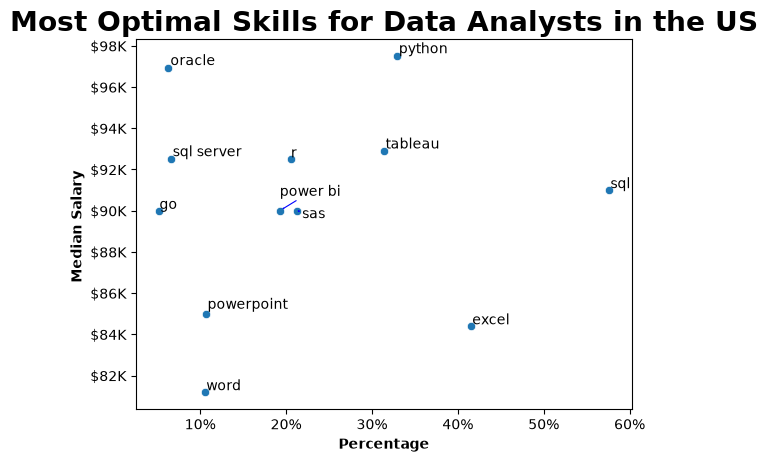

In [7]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

sns.scatterplot(data=df_DA_skills_high_demand, x='skill_percentage' , y='median_sal')
# putting the names on top of the points in scatter 

texts=[]

for index, skill in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[index], df_DA_skills_high_demand['median_sal'].iloc[index] , skill ))
    
adjust_text(texts,arrowprops=dict(arrowstyle='->', color='b',lw=0.8 ))
plt.title("Most Optimal Skills for Data Analysts in the US", weight='bold', fontsize=20)
plt.xlabel("Percentage", weight='bold', fontsize=10)
plt.ylabel("Median Salary ", weight='bold', fontsize=10)
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,  pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())



## 3. Determining which technologies are prelevent

In [13]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['tableau',
  'ms access',
  'visio',
  'dax',
  'sharepoint',
  'ssis',
  'powerbi',
  'splunk',
  'qlik',
  'outlook',
  'power bi',
  'excel',
  'esquisse',
  'spreadsheet',
  'sas',
  'looker',
  'word',
  'powerpoint',
  'msaccess',
  'sheets',
  'sap',
  'nuix',
  'cognos',
  'ssrs',
  'spss',
  'datarobot',
  'microstrategy',
  'alteryx'],
 'programming': ['vba',
  'dart',
  'golang',
  'c++',
  'no-sql',
  'nosql',
  'powershell',
  'mongodb',
  'julia',
  'delphi',
  'r',
  'visualbasic',
  'solidity',
  'groovy',
  'scala',
  'cobol',
  'pascal',
  'lua',
  'apl',
  'typescript',
  'visual basic',
  'c#',
  'shell',
  'css',
  'swift',
  'sas',
  'kotlin',
  'matlab',
  'sql',
  'rust',
  'elixir',
  'crystal',
  'java',
  'javascript',
  'php',
  'clojure',
  'bash',
  'html',
  'mongo',
  't-sql',
  'python',
  'c',
  'ruby',
  'haskell',
  'fortran',
  'erlang',
  'ocaml',
  'lisp',
  'assembly',
  'vb.net',
  'objective-c',
  'perl',
  'f#',
  'go',
  's

In [14]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,tableau
0,analyst_tools,ms access
0,analyst_tools,visio
0,analyst_tools,dax
0,analyst_tools,sharepoint
...,...,...
9,sync,twilio
9,sync,ringcentral
9,sync,unify
9,sync,google chat


In [22]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')
skill_limit= 5
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percentage'] > skill_limit]

## Final plot with technology


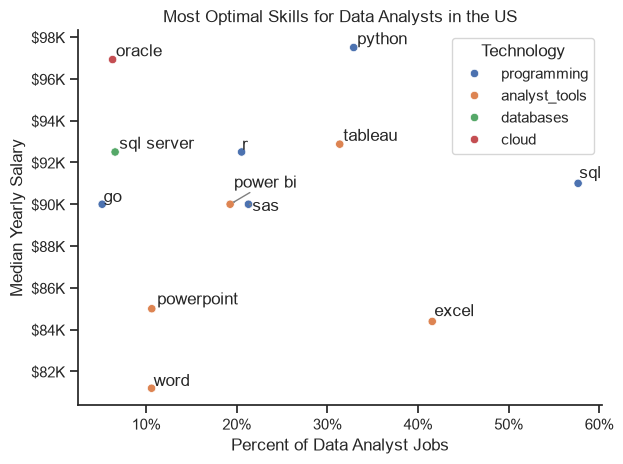

In [26]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skill_percentage',
    y='median_sal',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_sal'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()
